<a href="https://colab.research.google.com/github/mariiam36/EML_MontesinosOlivaOuardi/blob/main/Entornos_Complejos/Control_Aproximaciones/Sarsa_SemiGradiente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MLE - Práctica 1 parte 3**
***Máster en Inteligencia Artificial - Universidad de Murcia***

**Hecho por**: 
- Jorge Montesinos Bravo
- Manuel Oliva Marín
- Mariam Ouardi Bennane

**Profesor**: Luis Daniel Hernández Molinero

**Fecha**: 15/03/2026

# **Preparación del entorno**

In [ ]:
%git clone https://github.com/mariiam36/EML_MontesinosOlivaOuardi.git
%cd EML_MontesinosOlivaOuardi/Entornos_Complejos/Control_Aproximaciones

In [ ]:
#@title Importamos las librerias necesarias
# Computación numérica y visualización
import numpy as np
import matplotlib.pyplot as plt

# Entornos de Reinforcement Learning
from environments.mountain_car import make_mountain_car_env

# Discretización y utilidades del proyecto
from utils.discretizar import StateAggregationEnv
from utils.plotting import plot_curve

# Algoritmos y políticas
from algorithms.sarsa import SARSAApprox
# Semilla para reproducibilidad
from utils.fix_seed import fix_seed

In [ ]:
#@title Cargamos el entorno
NUM_EPISODES = 15000
SEED = 100
BIN_SIZE = 20

fix_seed(SEED)
env = make_mountain_car_env(seed=SEED, render_mode="rgb_array")

print("Estados:", env.observation_space)
print("Acciones:", env.action_space)

Estados: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Acciones: Discrete(3)


### Las acciones del entorno

La acciones disponibles son:
- 0: Acelerar a la izquierda.
- 1: No acelerar
- 2: Acelerar a la derecha

### Los estados del entorno

Las observaciones es un ndarray con dimensión (2,) donde los elementos se corresponde a los siguientes valores:

| Número | Observación                          | Mínimo | Máximo | Unidad        |
|--------|--------------------------------------|--------|--------|---------------|
| 0      | Posición del coche en el eje x      | -1.2   | 0.6    | posición (m)  |
| 1      | Velocidad del coche                 | -0.07  | 0.07   | velocidad (v) |


### Discretización

Podemos pasar de un espacio continuo de observaciones $[-1.2, 0.6]\times [-0.07, 0.07]$ a un espacio discreto. Para ello, discretizamos cada dimensión con una partición de intervalos. A esto se le llama **agregación.**

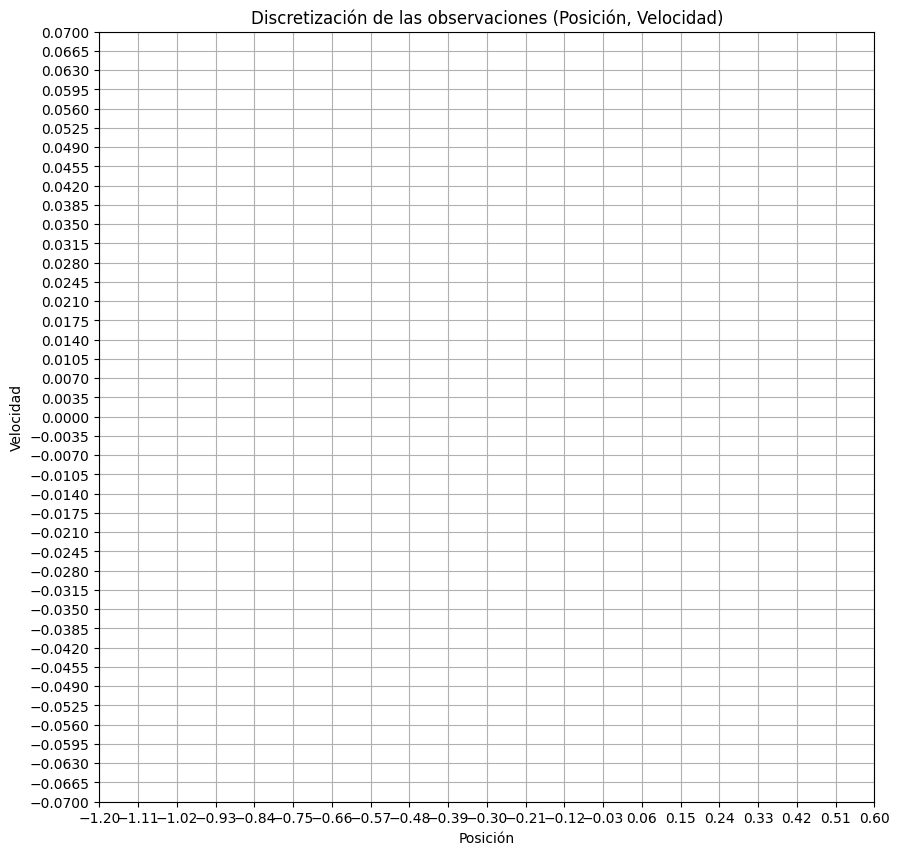

In [10]:
#@title Por ejemplo, podemos discretizar el espacio en solo 25 observaciones
# Definir los rangos para la posición y la velocidad
x_min, x_max = -1.2, 0.6    # Rango para la posición (eje X)
y_min, y_max = -0.07, 0.07  # Rango para la velocidad (eje Y)

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(10, 10))

# Establecer los límites de los ejes
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Dividir el eje X en 5 partes (6 ticks) y el eje Y en 5 partes (6 ticks)
x_ticks = np.linspace(x_min, x_max, 21)
y_ticks = np.linspace(y_min, y_max, 41)

# Asignar los ticks a los ejes
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

# Activar la grilla para mostrar las divisiones
ax.grid(True)

# Etiquetas y título para la gráfica
ax.set_xlabel("Posición")
ax.set_ylabel("Velocidad")
ax.set_title("Discretización de las observaciones (Posición, Velocidad)")

# Mostrar la gráfica
plt.show()

### Creamos *una* agregación de estados

- Necesitamos hacer un Wrapper sobre el espacio de observaciones.
- La posición se discretiza en 20 valores y la velocidad en 40 valores (el doble). La velocidad del agente es más importante.
- Por lo tanto, vamos a discretizar para trabajar con 800 estados. 

In [ ]:
#@title Dividimos cada dimensión en 20 intervalos. Al nuevo espacio lo llamaremos *saenv*
bins = np.array([BIN_SIZE, BIN_SIZE*2])
low = env.observation_space.low
high = env.observation_space.high
saenv = StateAggregationEnv(env, bins=bins, low=low, high=high)
saenv.buckets

[array([-1.2       , -1.1       , -1.        , -0.90000004, -0.8000001 ,
        -0.70000005, -0.6       , -0.50000006, -0.40000004, -0.3       ,
        -0.20000005, -0.10000002,  0.        ,  0.10000002,  0.19999993,
         0.29999995,  0.39999998,  0.5       ,  0.6       ], dtype=float32),
 array([-0.07      , -0.06631579, -0.06263158, -0.05894737, -0.05526316,
        -0.05157895, -0.04789474, -0.04421053, -0.04052632, -0.0368421 ,
        -0.03315789, -0.02947368, -0.02578947, -0.02210526, -0.01842105,
        -0.01473684, -0.01105263, -0.00736842, -0.00368421,  0.        ,
         0.00368422,  0.00736842,  0.01105263,  0.01473685,  0.01842105,
         0.02210526,  0.02578948,  0.02947368,  0.03315789,  0.03684211,
         0.04052632,  0.04421053,  0.04789474,  0.05157895,  0.05526315,
         0.05894738,  0.06263158,  0.06631579,  0.07      ], dtype=float32)]

In [ ]:
#@title Comparamos el entorno original con el entorno con estados agregados
print(f"El espacio de observaciones original es: {env.observation_space}, \n\
Un estado para este espacio es: {env.observation_space.sample()}")
print(f"El espacio de estados modificado es: {saenv.observation_space}, \n\
Un estado para este espacio es: {saenv.observation_space.sample()}")

El espacio de observaciones original es: Box([-1.2  -0.07], [0.6  0.07], (2,), float32), 
Un estado para este espacio es: [-1.0573915  -0.04254889]
El espacio de estados modificado es: MultiDiscrete([20 40]), 
Un estado para este espacio es: [13 10]


# **Ejecución**

In [ ]:
def summarize_results(name, rewards):
    print(f"\n=== {name} ===")
    print(f"Máximo: {np.max(rewards):.2f}")
    print(f"Media últimos 100: {np.mean(rewards[-100:]):.2f}")
    print(f"Último episodio: {rewards[-1]:.2f}")

In [ ]:
#@title Aprendizaje SARSA semi-gradiente
state_dim = np.prod(saenv.observation_space.nvec)

sarsa_approx = SARSAApprox(
    saenv,
    feature_dim=state_dim,
    n_actions=saenv.action_space.n,
    alpha=0.05,
    discount_factor=0.99,
    epsilon=0.3
)

sarsa_rewards, sarsa_steps = sarsa_approx.train(NUM_EPISODES)

SARSA semi-gradiente: 100%|██████████| 15000/15000 [01:41<00:00, 148.03it/s]


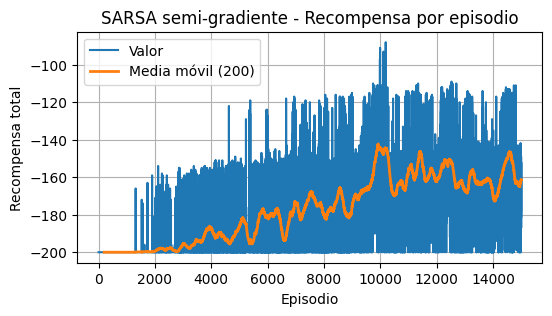

In [ ]:
#@title Recompensa por episodio
plot_curve(
    sarsa_rewards,
    title="SARSA semi-gradiente - Recompensa por episodio",
    ylabel="Recompensa total",
    moving_avg_window=200
)

In [ ]:
#@title Mostramos un resumen de los resultados
summarize_results("SARSA semi-gradiente", sarsa_rewards)


=== SARSA semi-gradiente ===
Máximo: -88.00
Media últimos 100: -161.49
Último episodio: -181.00


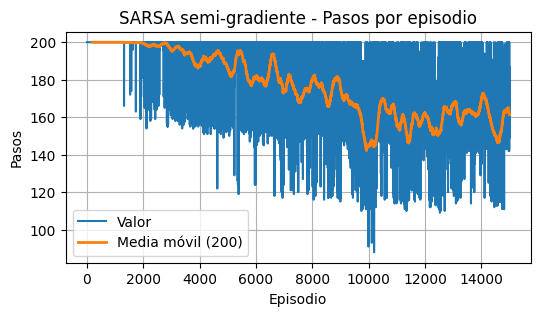

In [ ]:
#@title Longitud de episodio por número de episodios
plot_curve(
    sarsa_steps,
    title="SARSA semi-gradiente - Pasos por episodio",
    ylabel="Pasos",
    moving_avg_window=200
)

In [ ]:
#@title Inspección del modelo aprendido
print("Shape de theta:", sarsa_approx.theta.shape)
print("Norma de los pesos:", np.linalg.norm(sarsa_approx.theta))

Shape de theta: (3, 800)
Norma de los pesos: 1541.8353941345877


In [ ]:
#@title Política greedy obtenida
print("Secuencia de acciones greedy:", sarsa_approx.greedy_trajectory())

# **Fin**